In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.contingency import chi2_contingency

%matplotlib inline

## Initial idea of the dataset

In [52]:
df = pd.read_csv('Dataset/telco.csv')
df.shape

(7043, 50)

In [53]:
df

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,Female,30,No,No,No,No,0,United States,California,...,0,1639.44,3039.53,5,Stayed,No,45,5306,NaN,NaN
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2,United States,California,...,0,865.20,2807.47,3,Stayed,No,59,2140,NaN,NaN
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2,United States,California,...,0,2135.52,9453.04,4,Stayed,No,71,5560,NaN,NaN
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2,United States,California,...,0,0.00,319.21,4,Stayed,No,59,2793,NaN,NaN


In [54]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

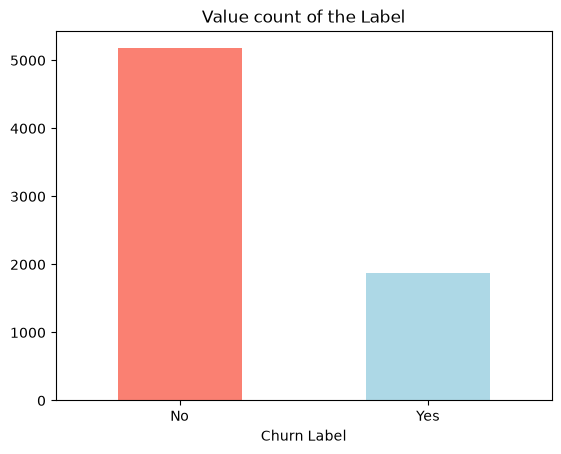

In [55]:
df['Churn Label'].value_counts().plot(kind="bar", color=["salmon", "lightblue"])
plt.title("Value count of the Label")
plt.xticks(rotation=0);

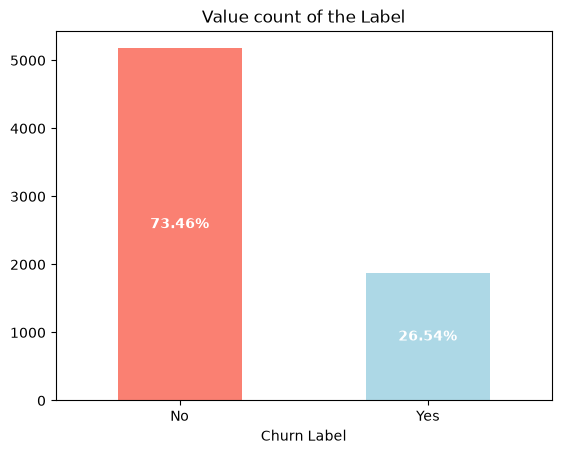

In [56]:
# 1. Store the value counts
counts = df['Churn Label'].value_counts()

# 2. Get the Axes object from the plot
ax = counts.plot(kind="bar", color=["salmon", "lightblue"])

# 3. Calculate total count for percentage calculation
total = len(df) # or counts.sum()

# 4. Add labels inside the bars
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    # Use padding and label_type to position inside the bar
    ax.annotate(
        percentage, 
        (p.get_x() + p.get_width() / 2., p.get_height() / 2), # Centered inside
        ha='center', 
        va='center', 
        color='white', 
        weight='bold'
    )

plt.title("Value count of the Label")
plt.xticks(rotation=0)
plt.show()

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   str    
 4   Senior Citizen                     7043 non-null   str    
 5   Married                            7043 non-null   str    
 6   Dependents                         7043 non-null   str    
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   str    
 9   State                              7043 non-null   str    
 10  City                               7043 non-null   str    
 11  Zip Code                           7043 non-null   int64  
 12  Lat

In [58]:
df.isna().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [59]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [60]:
df[df.duplicated()]

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason


In [61]:
df["Age"].describe()

count    7043.000000
mean       46.509726
std        16.750352
min        19.000000
25%        32.000000
50%        46.000000
75%        60.000000
max        80.000000
Name: Age, dtype: float64

In [62]:
df["Tenure in Months"].describe()

count    7043.000000
mean       32.386767
std        24.542061
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure in Months, dtype: float64

In [63]:
financial_cols = [
    "Monthly Charge",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges"
]

for col in financial_cols:
    print(
        col,
        "negative values:",
        (df[col] < 0).sum()
    )

Monthly Charge negative values: 0
Total Charges negative values: 0
Total Refunds negative values: 0
Total Extra Data Charges negative values: 0
Total Long Distance Charges negative values: 0


In [64]:
df[
    df["Internet Service"] == "No"
][
    [
        "Internet Service",
        "Online Security",
        "Online Backup",
        "Device Protection Plan",
        "Premium Tech Support",
        "Streaming TV",
        "Streaming Movies"
    ]
].value_counts()

Internet Service  Online Security  Online Backup  Device Protection Plan  Premium Tech Support  Streaming TV  Streaming Movies
No                No               No             No                      No                    No            No                  1526
Name: count, dtype: int64

In [65]:
df['Gender'].value_counts()

Gender
Male      3555
Female    3488
Name: count, dtype: int64

In [66]:
# Compare gender column with target column
pd.crosstab(df['Churn Label'], df['Gender'])

Gender,Female,Male
Churn Label,,
No,2549,2625
Yes,939,930


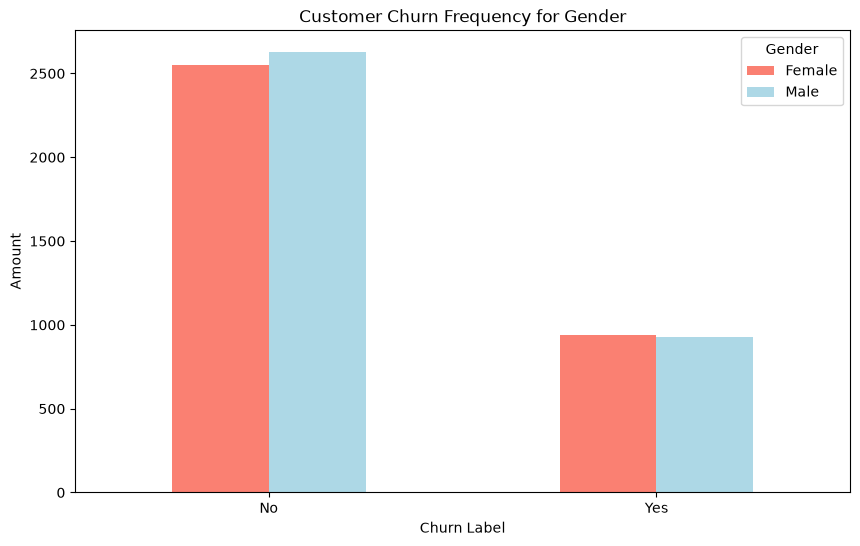

In [67]:
# Create a plot for Gender, Churn Lable crosstab
pd.crosstab(df['Churn Label'], df['Gender']).plot(kind='bar',
                                                  figsize=(10, 6),
                                                  color=["salmon", "lightblue"])

plt.title("Customer Churn Frequency for Gender")
plt.ylabel("Amount")
plt.xticks(rotation=0);

In [68]:
df['Contract'].value_counts()

Contract
Month-to-Month    3610
Two Year          1883
One Year          1550
Name: count, dtype: int64

In [69]:
pd.crosstab(df['Churn Label'], df['Contract'])

Contract,Month-to-Month,One Year,Two Year
Churn Label,,,
No,1955,1384,1835
Yes,1655,166,48


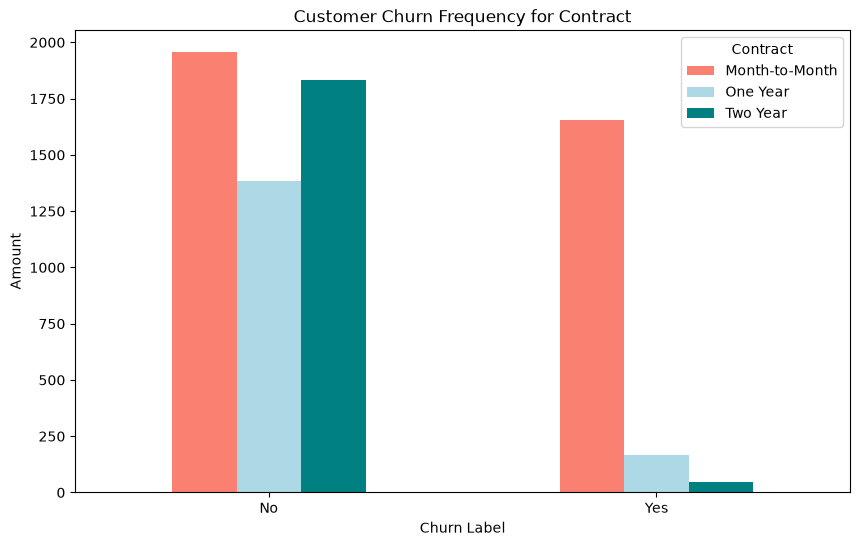

In [70]:
# Create a plot for Contract, Churn Lable crosstab
pd.crosstab(df['Churn Label'], df['Contract']).plot(kind='bar',
                                                  figsize=(10, 6),
                                                  color=["salmon", "lightblue", "teal"])

plt.title("Customer Churn Frequency for Contract")
plt.ylabel("Amount")
plt.xticks(rotation=0);

In [71]:
df['Unlimited Data'].value_counts()

Unlimited Data
Yes    4745
No     2298
Name: count, dtype: int64

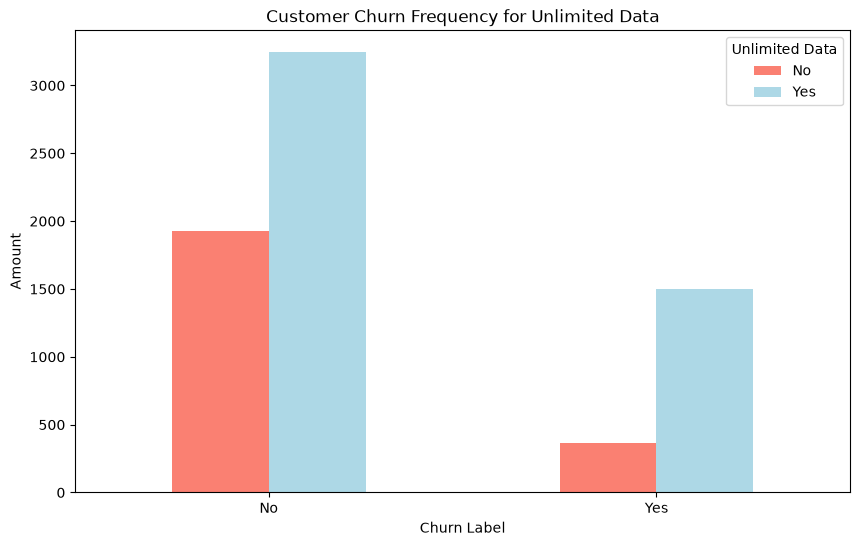

In [72]:
# Create a plot for Unlimited Data, Churn Lable crosstab
pd.crosstab(df['Churn Label'], df['Unlimited Data']).plot(kind='bar',
                                                  figsize=(10, 6),
                                                  color=["salmon", "lightblue"])

plt.title("Customer Churn Frequency for Unlimited Data")
plt.ylabel("Amount")
plt.xticks(rotation=0);

In [73]:
df['Satisfaction Score'].value_counts()

Satisfaction Score
3    2665
4    1789
5    1149
1     922
2     518
Name: count, dtype: int64

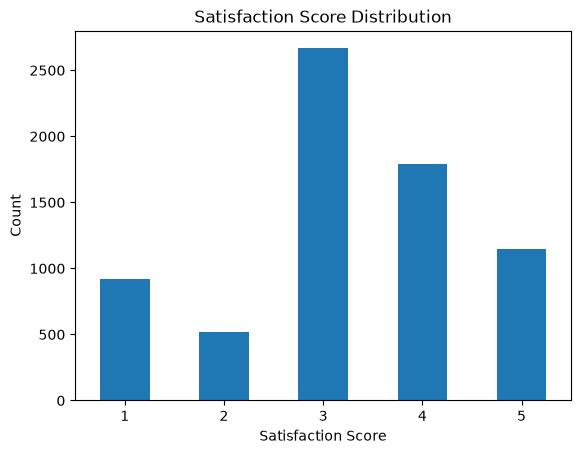

In [74]:
df['Satisfaction Score'].value_counts().sort_index().plot(
    kind='bar', 
    rot=0,
    title='Satisfaction Score Distribution',
    xlabel='Satisfaction Score',
    ylabel='Count'
)

plt.show()

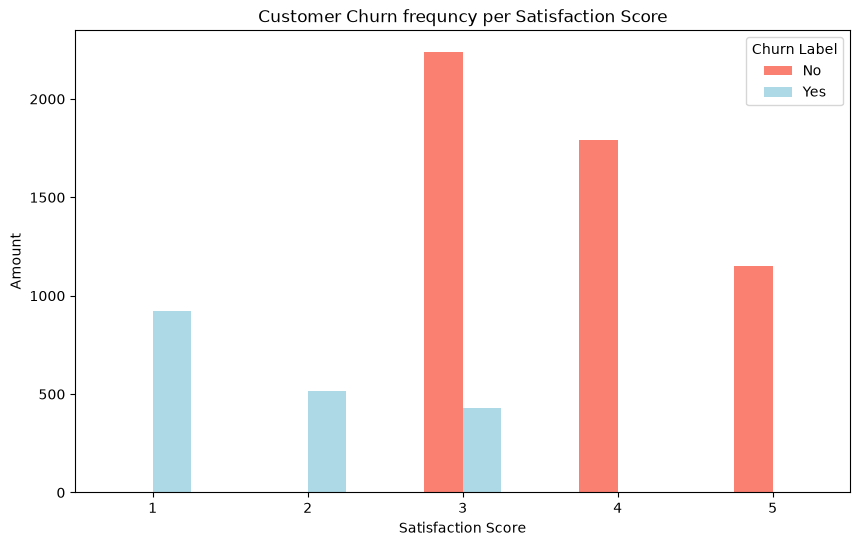

In [75]:
# Customer Churn frequncy per Satisfaction Score
pd.crosstab(df["Satisfaction Score"], df["Churn Label"]).plot(kind="bar",figsize=(10, 6),color=["salmon", "lightblue"])

# Add some communication
plt.title("Customer Churn frequncy per Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Amount")
# plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0);

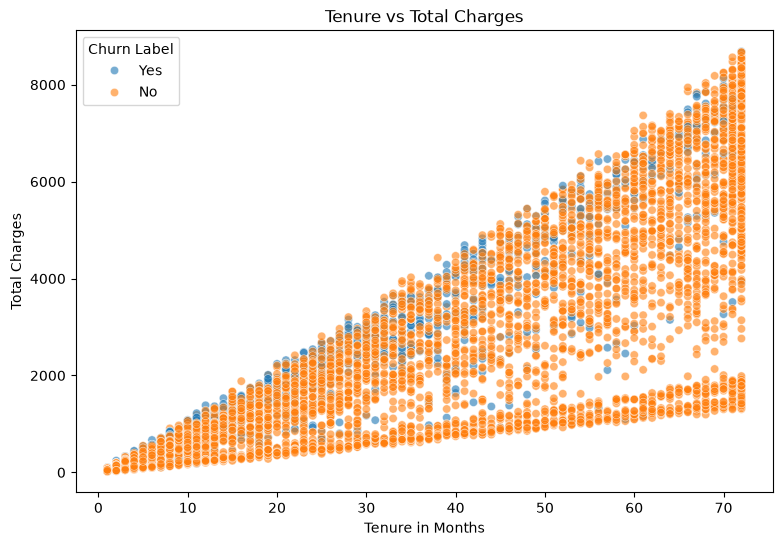

In [76]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Tenure in Months",
    y="Total Charges",
    hue="Churn Label",
    alpha=0.6
)
plt.title("Tenure vs Total Charges")
plt.show()

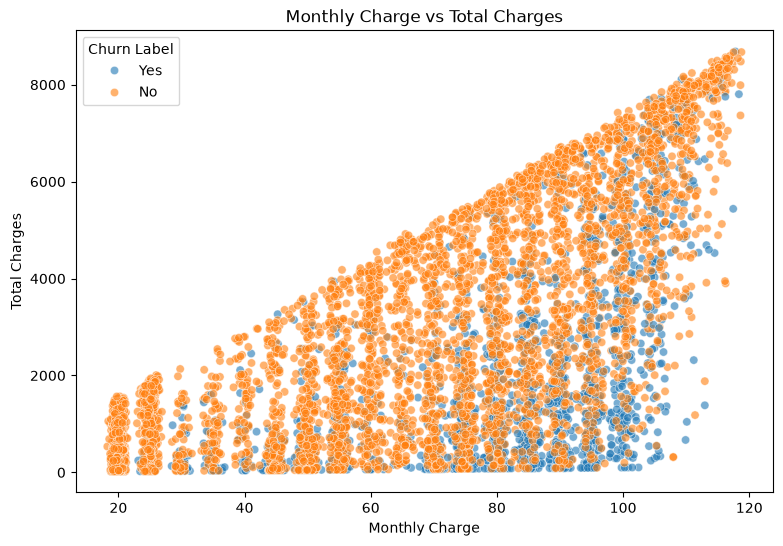

In [77]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Monthly Charge",
    y="Total Charges",
    hue="Churn Label",
    alpha=0.6
)
plt.title("Monthly Charge vs Total Charges")

plt.show()

## Correlation Matrix

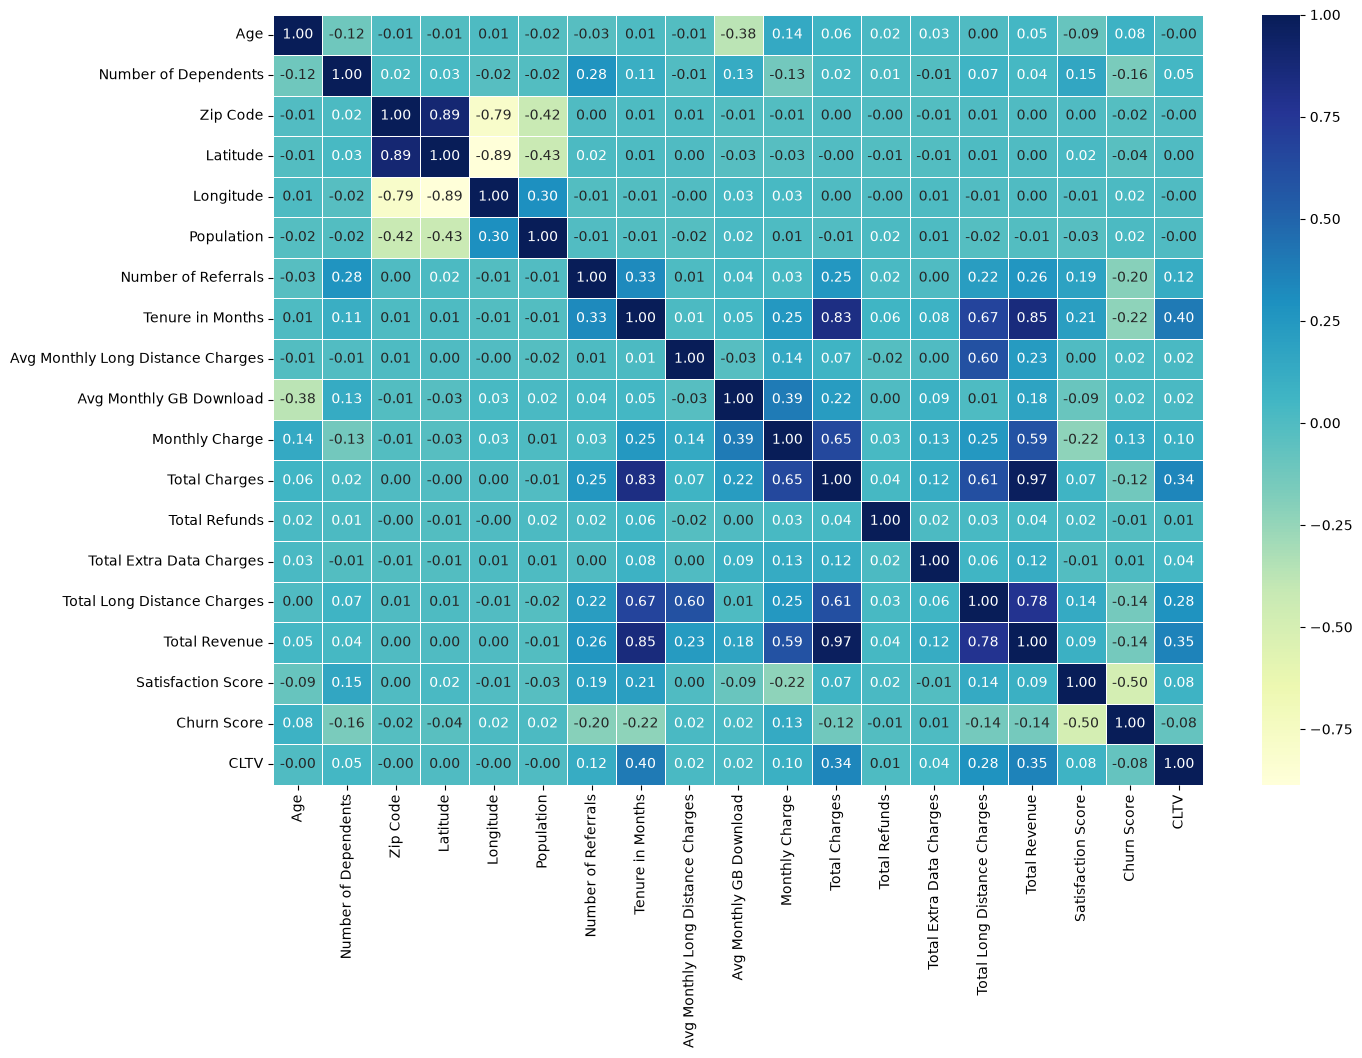

In [78]:
# Make a correlation matrix
corr_matrix = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidths=0.5,
                 fmt=".2f",
                 cmap="YlGnBu");

## Identify Outliers

In [79]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['Age',
 'Number of Dependents',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Population',
 'Number of Referrals',
 'Tenure in Months',
 'Avg Monthly Long Distance Charges',
 'Avg Monthly GB Download',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Satisfaction Score',
 'Churn Score',
 'CLTV']

In [80]:
outlier_cols = [
    "Age",
    "Number of Dependents",
    "Number of Referrals",
    "Tenure in Months",
    "Monthly Charge",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Population",
    "CLTV"
]

[col for col in outlier_cols if col not in df.columns]

[]

In [81]:
# IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return {
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": len(outliers) / len(df) * 100
    }

In [82]:
outlier_results = []

for col in outlier_cols:
    outlier_results.append(
        detect_outliers_iqr(df, col)
    )

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary.sort_values(
    "Outlier %",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
1,Number of Dependents,0.000,0.00,0.000,0.0000,0.0000,1627,23.100951
7,Total Extra Data Charges,0.000,0.00,0.000,0.0000,0.0000,728,10.336504
2,Number of Referrals,0.000,3.00,3.000,-4.5000,7.5000,676,9.598183
6,Total Refunds,0.000,0.00,0.000,0.0000,0.0000,525,7.454210
8,Total Long Distance Charges,70.545,1191.10,1120.555,-1610.2875,2871.9325,196,2.782905
9,Population,2344.000,36125.00,33781.000,-48327.5000,86796.5000,57,0.809314
0,Age,32.000,60.00,28.000,-10.0000,102.0000,0,0.000000
5,Total Charges,400.150,3786.60,3386.450,-4679.5250,8866.2750,0,0.000000
4,Monthly Charge,35.500,89.85,54.350,-46.0250,171.3750,0,0.000000
3,Tenure in Months,9.000,55.00,46.000,-60.0000,124.0000,0,0.000000


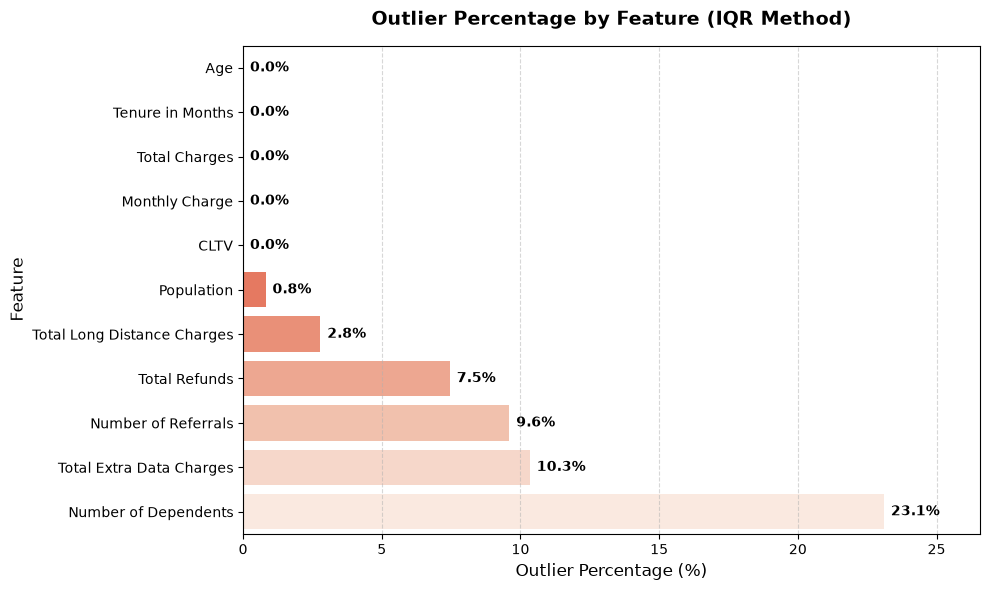

In [83]:
# Sort DataFrame by Outlier % ascending so highest appears at the top of the horizontal chart
outlier_summary_sorted = outlier_summary.sort_values("Outlier %", ascending=True)

plt.figure(figsize=(10, 6))

# Horizontal barplot
ax = sns.barplot(
    data=outlier_summary_sorted,
    x="Outlier %",
    y="Feature",
    hue="Feature",
    palette="Reds_r",
    legend=False
)

# Add data labels to the ends of each bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.1f}%',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        weight='bold'
    )

plt.title("Outlier Percentage by Feature (IQR Method)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Outlier Percentage (%)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xlim(0, max(outlier_summary["Outlier %"].max() * 1.15, 1))  # Extend x-axis to fit annotations cleanly
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Identify Data Leakage

In [84]:
pd.crosstab(df["Customer Status"], df["Churn Label"])

Churn Label,No,Yes
Customer Status,,
Churned,0,1869
Joined,454,0
Stayed,4720,0


In [85]:
reasons = df["Churn Reason"][df["Churn Reason"].notna()]
reasons = reasons.value_counts().to_frame()
reasons.index.name = "Churn Reason"
reasons.columns = ["counts"]
reasons = reasons.assign(percent=lambda x: x / reasons["counts"].sum())

formater = lambda x: f"{x:.2%}"
reasons["percent"] = reasons.percent.apply(formater)
reasons.reset_index(inplace=True)
reasons

,Churn Reason,counts,percent
0,Competitor had better devices,313,16.75%
1,Competitor made better offer,311,16.64%
2,Attitude of support person,220,11.77%
3,Don't know,130,6.96%
4,Competitor offered more data,117,6.26%
5,Competitor offered higher download speeds,100,5.35%
6,Attitude of service provider,94,5.03%
7,Price too high,78,4.17%
8,Product dissatisfaction,77,4.12%
9,Network reliability,72,3.85%


## Hypothesis Testing

#### Hypothesis 1: Phone Service impact chrun
* H0: There is no significant relationship between `Phone Service` and `Churn`
* H1: There is a significant relationship between `Phone Service` and `Churn`

#### Hypothesis 2: Contract type affects churn
* H0: The `type of contract` does not affect the likelihood of churn.
* H1: The `type of contract` significantly influences the likelihood of churn

#### Hypothesis 3: Seniority affects churn
* H0: The `The Senior Citizen` does not affect the likelihood of churn.
* H1: The `The Senior Citizen` significantly influences the likelihood of churn

In [88]:
def chi_square_test(dataframe: DataFrame):
    columns = ["Phone Service", "Contract", "Senior Citizen"]
    p_value = []
    dofs = []
    chi_square = []

    for column in columns:
        crosstab = pd.crosstab(index=dataframe[column], columns=dataframe["Churn Label"])
        chi_value, p, dof, ev = chi2_contingency(crosstab)
        chi_square.append(chi_value)
        dofs.append(dof)
        p_value.append(p)

    return pd.DataFrame({
        "column": columns,
        "test_statistic": np.round(chi_square),
        "degreee_of_freedom": dof,
        "p_value": np.round(p_value, 2)
    })

In [89]:
chi_table = chi_square_test(df)
chi_table["Decision"] = np.where(
    chi_table.p_value < 0.05, "significant", "not significant"
)
chi_table

,column,test_statistic,degreee_of_freedom,p_value,Decision
0,Phone Service,1.0,1,0.34,not significant
1,Contract,1445.0,1,0.00,significant
2,Senior Citizen,159.0,1,0.00,significant


#### Hypothesis 1: Phone Service impact chrun
* The p-value for the hypothesis testing related to `Phone Service` is 0.34, which is greater than the chosen alpha. Therefore, we `fail to reject` the null hypothesis.
  
#### Hypothesis 2: Contract type affects churn
* The p-value for the hypothesis testing related to `Contract` is 0.00, which is less than the chosen alpha. Therefore, we `reject` the null hypothesis.
  
#### Hypothesis 3: Seniority affects churn
* The p-value for the hypothesis testing related to `Senior Citizen` is 0.00, which is less than the chosen alpha. Therefore, we `reject` the null hypothesis.